<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_028_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 28/365 — Feature Engineering
## Can better features help a simple model learn more?

Feature engineering means creating useful input variables from existing data.

Today we keep the **same Linear Regression model** and only change the features.

We use scikit-learn's built-in **Diabetes regression dataset**.

**Question:** Can better feature representation improve the same model?


## What we compare

**Baseline:** original features only

**Engineered:** original features plus:
- `bmi_squared`
- `bp_squared`
- `bmi_x_bp`

These let a linear model represent simple curved and interaction effects.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 1. Load the real dataset

In [2]:
diabetes = load_diabetes(as_frame=True)

X = diabetes.data.copy()
y = diabetes.target.copy()

print("Dataset shape:", X.shape)
print("Features:", X.columns.tolist())
display(X.head())

Dataset shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 2. Create engineered features

In [3]:
X_engineered = X.copy()

X_engineered["bmi_squared"] = X_engineered["bmi"] ** 2
X_engineered["bp_squared"] = X_engineered["bp"] ** 2
X_engineered["bmi_x_bp"] = X_engineered["bmi"] * X_engineered["bp"]

print("Original features:", X.shape[1])
print("Engineered features:", X_engineered.shape[1])

display(
    X_engineered[
        ["bmi", "bp", "bmi_squared", "bp_squared", "bmi_x_bp"]
    ].head()
)

Original features: 10
Engineered features: 13


,bmi,bp,bmi_squared,bp_squared,bmi_x_bp
0,0.061696,0.021872,0.003806,0.000478,0.001349
1,-0.051474,-0.026328,0.002650,0.000693,0.001355
2,0.044451,-0.005670,0.001976,0.000032,-0.000252
3,-0.011595,-0.036656,0.000134,0.001344,0.000425
4,-0.036385,0.021872,0.001324,0.000478,-0.000796


## 3. Compare both versions with 5-fold cross-validation

Lower RMSE is better.


In [4]:
model = LinearRegression()

cv = KFold(n_splits=5, shuffle=True, random_state=42)

baseline_rmse = -cross_val_score(
    model, X, y, cv=cv,
    scoring="neg_root_mean_squared_error"
)

engineered_rmse = -cross_val_score(
    model, X_engineered, y, cv=cv,
    scoring="neg_root_mean_squared_error"
)

print("Baseline RMSE:", np.round(baseline_rmse, 2))
print("Engineered RMSE:", np.round(engineered_rmse, 2))

print("\nBaseline mean RMSE:", round(baseline_rmse.mean(), 2))
print("Engineered mean RMSE:", round(engineered_rmse.mean(), 2))

Baseline RMSE: [53.85 51.6  57.55 52.9  58.34]
Engineered RMSE: [52.8  53.45 56.98 54.01 57.66]

Baseline mean RMSE: 54.85
Engineered mean RMSE: 54.98


## 4. Visual — Original vs engineered features

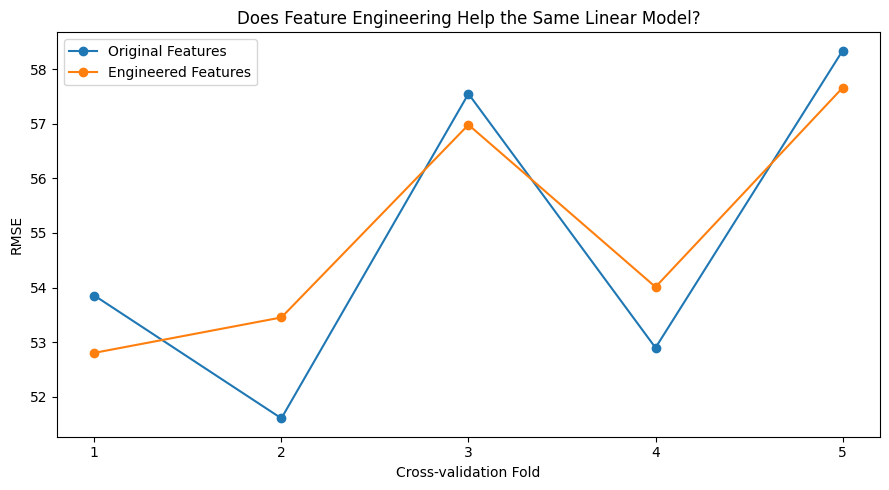

In [5]:
folds = np.arange(1, 6)

plt.figure(figsize=(9, 5))

plt.plot(folds, baseline_rmse, marker="o", label="Original Features")
plt.plot(folds, engineered_rmse, marker="o", label="Engineered Features")

plt.xlabel("Cross-validation Fold")
plt.ylabel("RMSE")
plt.title("Does Feature Engineering Help the Same Linear Model?")
plt.xticks(folds)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Final hold-out test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_eng_train = X_engineered.loc[X_train.index]
X_eng_test = X_engineered.loc[X_test.index]

baseline_model = LinearRegression()
engineered_model = LinearRegression()

baseline_model.fit(X_train, y_train)
engineered_model.fit(X_eng_train, y_train)

baseline_pred = baseline_model.predict(X_test)
engineered_pred = engineered_model.predict(X_eng_test)

results = pd.DataFrame({
    "Model": ["Original Features", "Engineered Features"],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, baseline_pred)),
        np.sqrt(mean_squared_error(y_test, engineered_pred))
    ],
    "Test R2": [
        r2_score(y_test, baseline_pred),
        r2_score(y_test, engineered_pred)
    ]
})

display(results.round(3))

,Model,Test RMSE,Test R2
0,Original Features,53.853,0.453
1,Engineered Features,52.802,0.474


## What does this prove?

- The **algorithm stayed the same**.
- Feature engineering changes what information the model can represent.
- Squared features can represent simple nonlinear relationships.
- Interaction features can represent cases where variables matter together.
- **More features are not automatically better.** New features must be validated on unseen data.

> A useful engineered feature does not prove causality. It only shows that the representation helped this predictive model.


## References

- scikit-learn — Diabetes dataset: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
- scikit-learn — Linear Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- scikit-learn — Cross-validation: https://scikit-learn.org/stable/modules/cross_validation.html
- Google ML Crash Course — Numerical data: https://developers.google.com/machine-learning/crash-course/numerical-data
